# Gold nanoparticle reconstruction in quantem 

Notebook from Georgios Varnavides and Stephanie Ribet

Data collected by Stephanie Ribet, TEAM I, Jan 2025

In [1]:
%load_ext autoreload 
%autoreload 2

In [2]:
import numpy as np

import quantem as em
from quantem.core import config
from quantem.core.visualization import show_2d

config.set_device(1)
print(config.get("device"))

/home/sribet/micromamba/envs/quantem/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda:1


# load data

In [ ]:
# Data can be downloaded from https://doi.org/10.5281/zenodo.18449974
dc = em.io.load("data/gold_arina_calibrated.zip")

In [6]:
# calibrations
PROBE_SEMIANGLE = 21.9
ENERGY = 300e3
SCAN_WIDTH = dc.array.shape[0]
FOV = 340 #A

In [8]:
dc.array.shape

(256, 256, 192, 192)

In [11]:
dc.get_dp_mean()

Dataset(shape=(192, 192), dtype=float64, name='4D-STEM dataset_dp_mean')
  sampling: [1. 1.]
  units: ['pixels', 'pixels']
  signal units: 'arb. units'

# direct ptycho

In [14]:
direct_ptycho = em.diffractive_imaging.direct_ptychography.DirectPtychography.from_dataset4d(
    dc,
    energy=ENERGY,
    semiangle_cutoff=PROBE_SEMIANGLE,
    aberration_coefs={},
    device="gpu",
    rotation_angle=np.deg2rad(-169), # known rotation
    max_batch_size=32
)


# direct ptycho: optimize

In [15]:
from quantem.diffractive_imaging.direct_ptychography import OptimizationParameter
direct_ptycho.optimize_hyperparameters(
    aberration_coefs={
        "C10":OptimizationParameter(-400,400),
        "C12":OptimizationParameter(0, 100),
        "phi12":OptimizationParameter(-np.pi/2, np.pi/2)
    },
    rotation_angle=np.deg2rad(-169),
    deconvolution_kernel='quadratic',
)



Best trial: 49. Best value: 0.0535198: 100%|████| 50/50 [00:13<00:00,  3.77it/s]


Optimized parameters: {'C10': -356.9529812795785, 'C12': 78.64523091829938, 'phi12': 0.1933271962475496}


100%|████████████████████████████████████| 7211/7211 [00:00<00:00, 17104.19it/s]


(<Figure size 400x400 with 1 Axes>, <Axes: >)

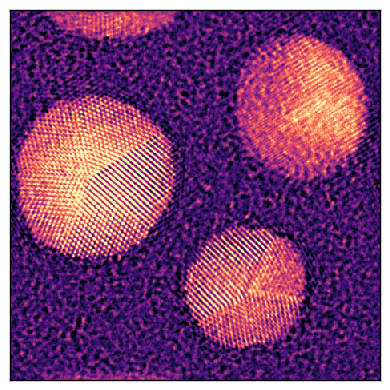

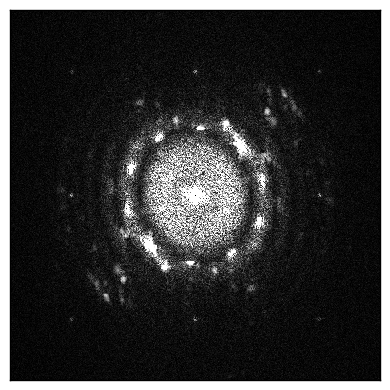

In [16]:
initial_parallax = direct_ptycho.reconstruct_with_optimized_parameters(
    upsampling_factor = 3,
    deconvolution_kernel='quadratic',
    max_batch_size = 32,
)

show_2d(initial_parallax.obj, cmap = "magma")


show_2d(np.fft.fftshift(np.abs(np.fft.fft2(initial_parallax.obj))))

# iterative ptycho

In [17]:
from quantem.core.datastructures import Dataset4dstem
from quantem.diffractive_imaging.dataset_models import PtychographyDatasetRaster
from quantem.diffractive_imaging.ptychography_lite import PtychoLite, PtychoLiteDIP

Forcing best fit rotation to -169 degrees.
Forcing transpose of intensities to False.


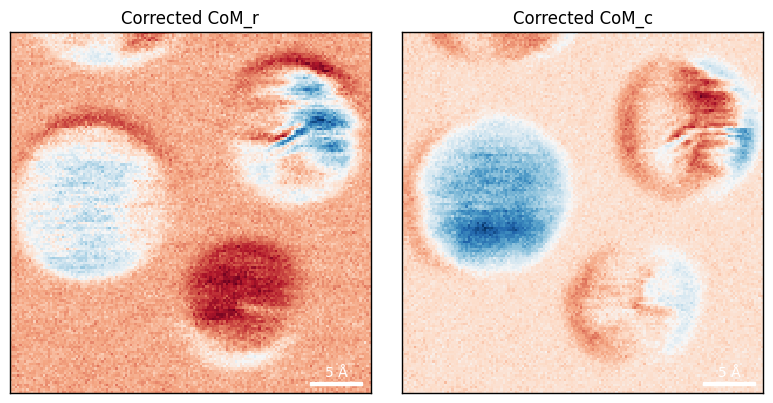

Normalizing intensities: 100%|█| 23716/23716 [00:41<00:00, 577.78probe position/


In [18]:
pdset = PtychographyDatasetRaster.from_dataset4dstem(dc)

pdset.preprocess(
    com_fit_function="constant",
    plot_rotation=True,
    plot_com=True,
    probe_energy=ENERGY,
    force_com_rotation=-169,
    force_com_transpose = False,
)


In [19]:
ptycho_pix = PtychoLite.from_dataset(
    dset=pdset,
    num_slices=8,
    obj_type="potential",
    num_probes=3,
    energy=ENERGY,
    semiangle_cutoff=PROBE_SEMIANGLE,
    obj_padding_px=(64,64),
    device="cpu",
    polar_parameters = {
        'C10': -330.33740092814674,
        'C12': 67.33092828772897, 
        'phi12': 0.00145768024663398,
    },
    middle_focus=True,
    slice_thicknesses=20,
    log_dir = "./logs",
    log_prefix="gold",
    log_images_every=5,
    log_probe_images=False,
)

Logging to logs/zongdag_gold_20251214_111552_pix


Iter 50/50, Loss: 1.251e+03: 100%|██████████████| 50/50 [16:41<00:00, 20.03s/it]


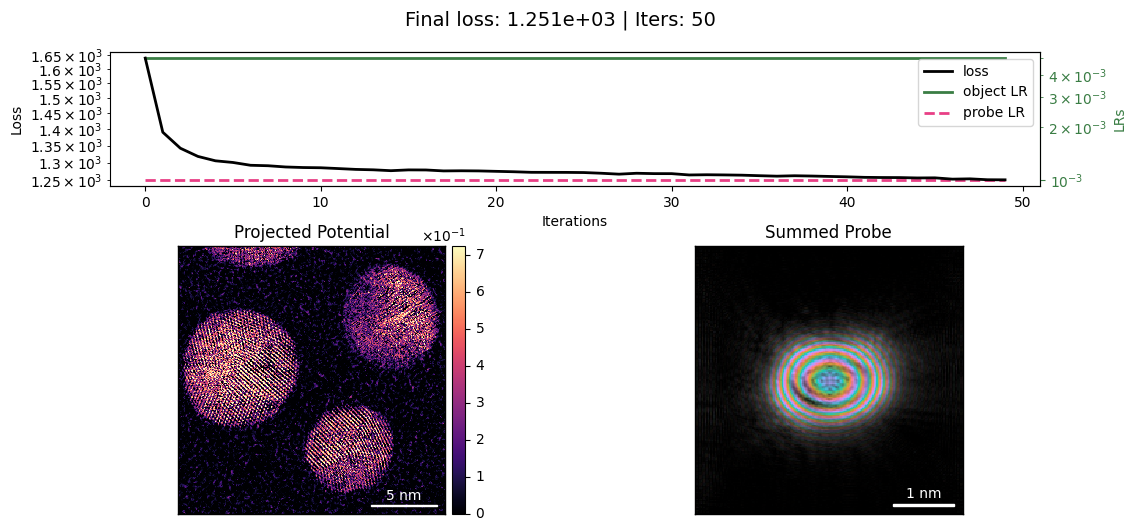

In [20]:
constraints = {
    "object":{
        "fix_potential_baseline": True,
        "fix_potential_baseline_factor": 0.5,
        "tv_weight_z": 1000,
    }
}
ptycho_pix.reconstruct(
    num_iters=50, 
    device="gpu", 
    batch_size=512,
    constraints=constraints,
    reset = True,
).visualize()


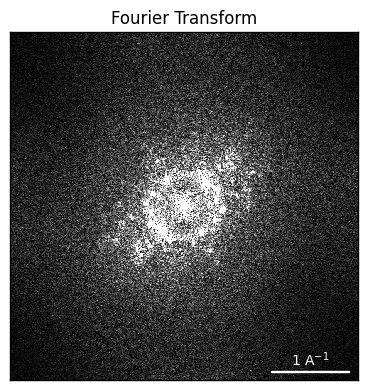

In [21]:
ptycho_pix.show_obj_fft()

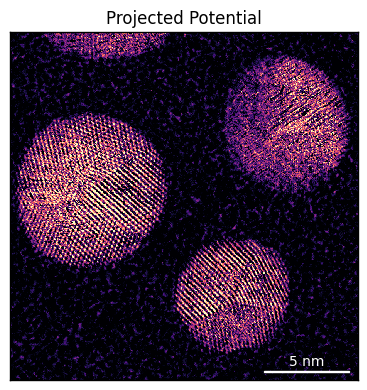

In [22]:
ptycho_pix.show_obj()

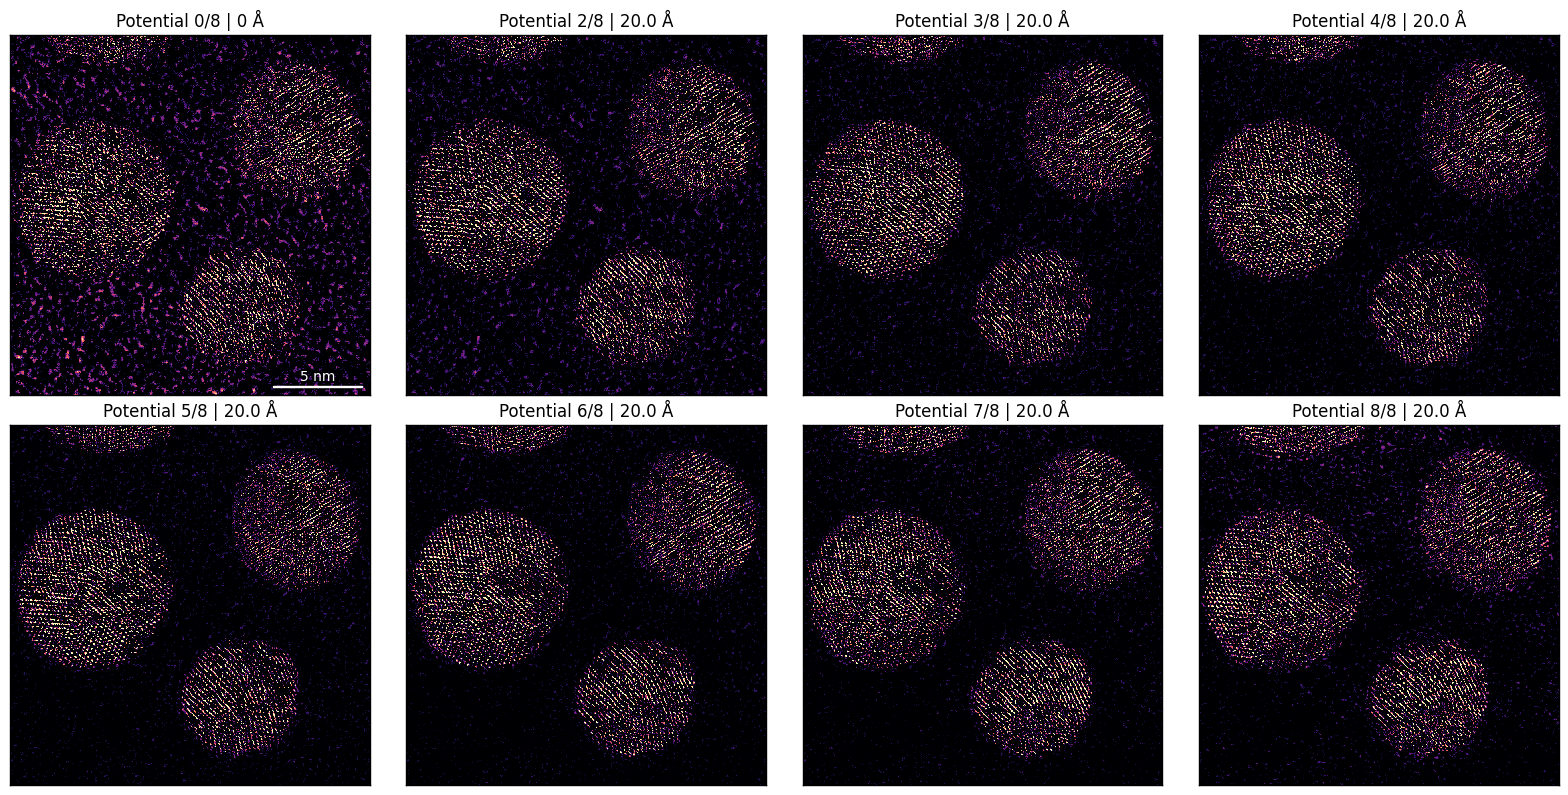

In [23]:
ptycho_pix.show_obj_slices()

# dip

Iter 150/150, Loss: 1.931e-03, : 100%|████████| 150/150 [00:18<00:00,  8.21it/s]


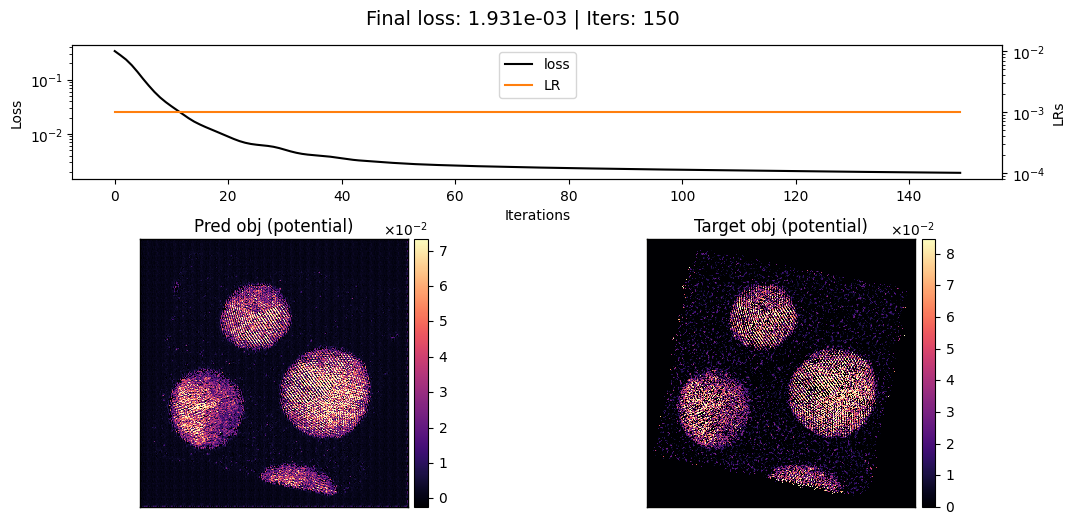

Iter 150/150, Loss: 7.705e-03, : 100%|████████| 150/150 [00:09<00:00, 15.46it/s]


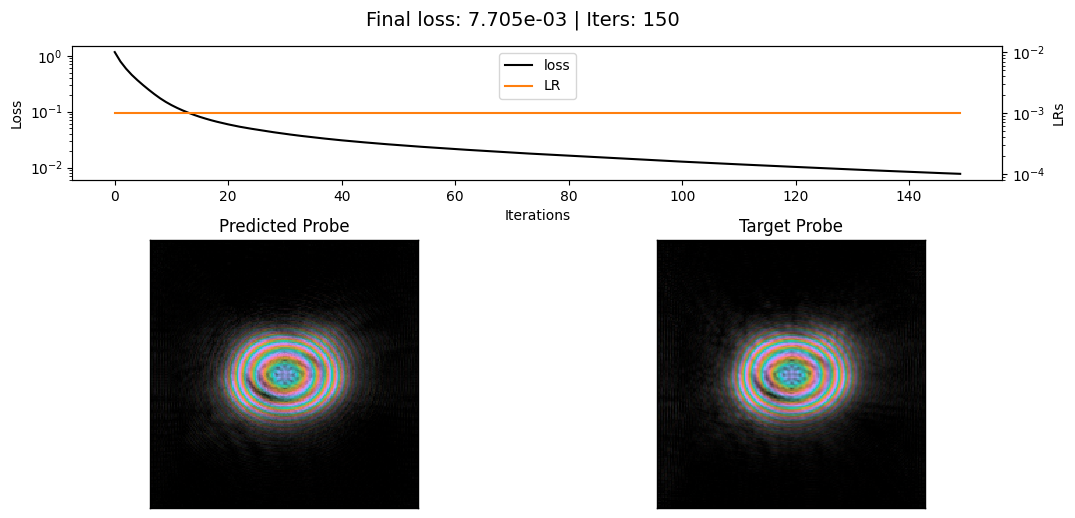

In [24]:
ptycho_dip = PtychoLiteDIP.from_ptycholite(
    ptycholite=ptycho_pix,
    pretrain_iters=150,
    device='gpu',
    # pretrain_object=False,
)

In [25]:
import gc
import torch 

torch.cuda.empty_cache()
gc.collect()

5940

Iter 5/5, Loss: 1.092e+03: 100%|██████████████████| 5/5 [03:08<00:00, 37.73s/it]


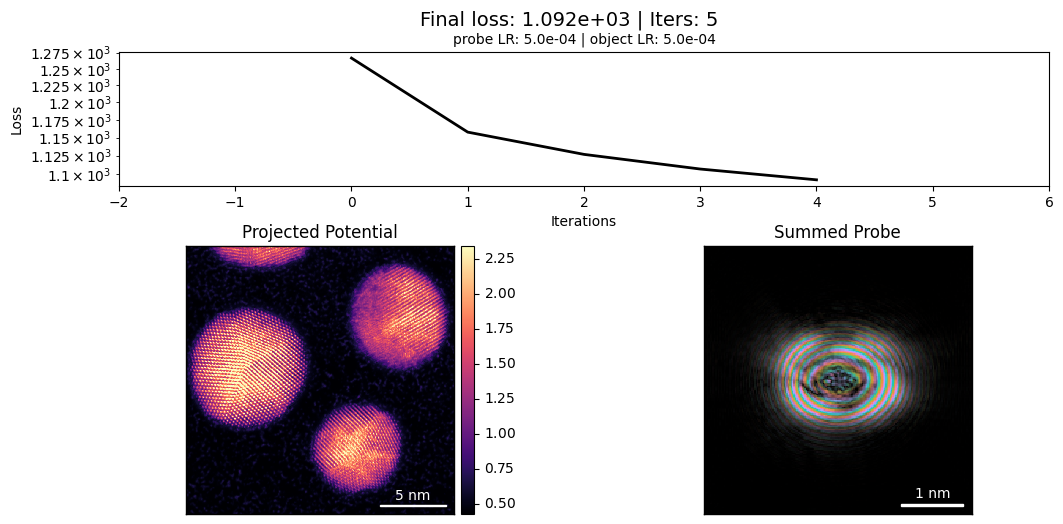

In [26]:

constraints = {
    "object":{
        "fix_potential_baseline": True,
        "fix_potential_baseline_factor": 0.5,
        "q_lowpass": 1.3,
        "identical_slices":True,
    }
}

ptycho_dip.reconstruct(
    num_iters=5, 
    reset=True, 
    scheduler_type='plateau', 
    batch_size=256,
    constraints=constraints
).visualize()


Iter 5/5, Loss: 1.060e+03: 100%|██████████████████| 5/5 [03:07<00:00, 37.56s/it]


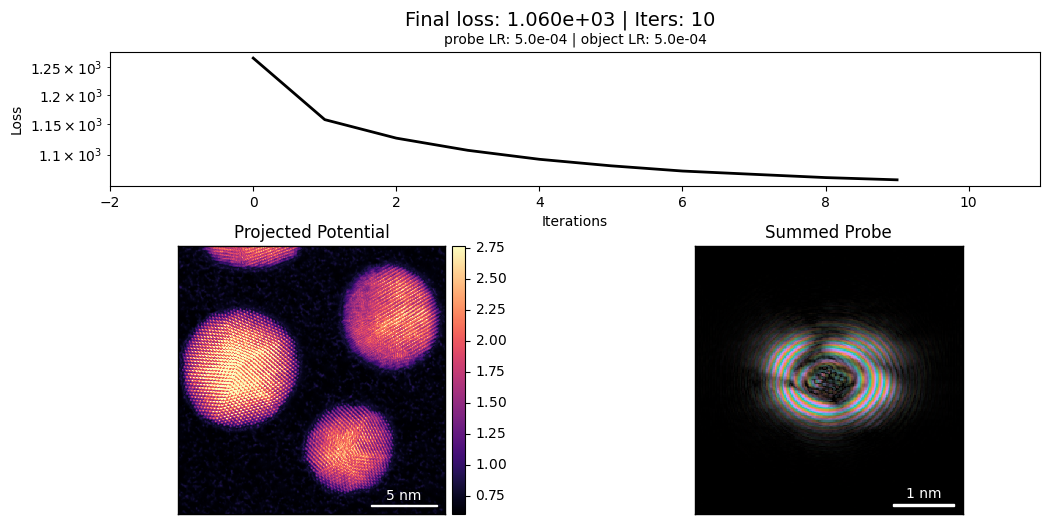

In [27]:
ptycho_dip.reconstruct(
    num_iters=5, 
    reset=False, 
    scheduler_type='plateau', 
    batch_size=256,
    constraints=constraints
).visualize()


(<Figure size 1200x1200 with 4 Axes>,
 array([[<Axes: title={'center': 'direct ptycho'}>,
         <Axes: title={'center': 'iterative ptycho'}>],
        [<Axes: title={'center': 'direct ptycho'}>,
         <Axes: title={'center': 'iterative ptycho'}>]], dtype=object))

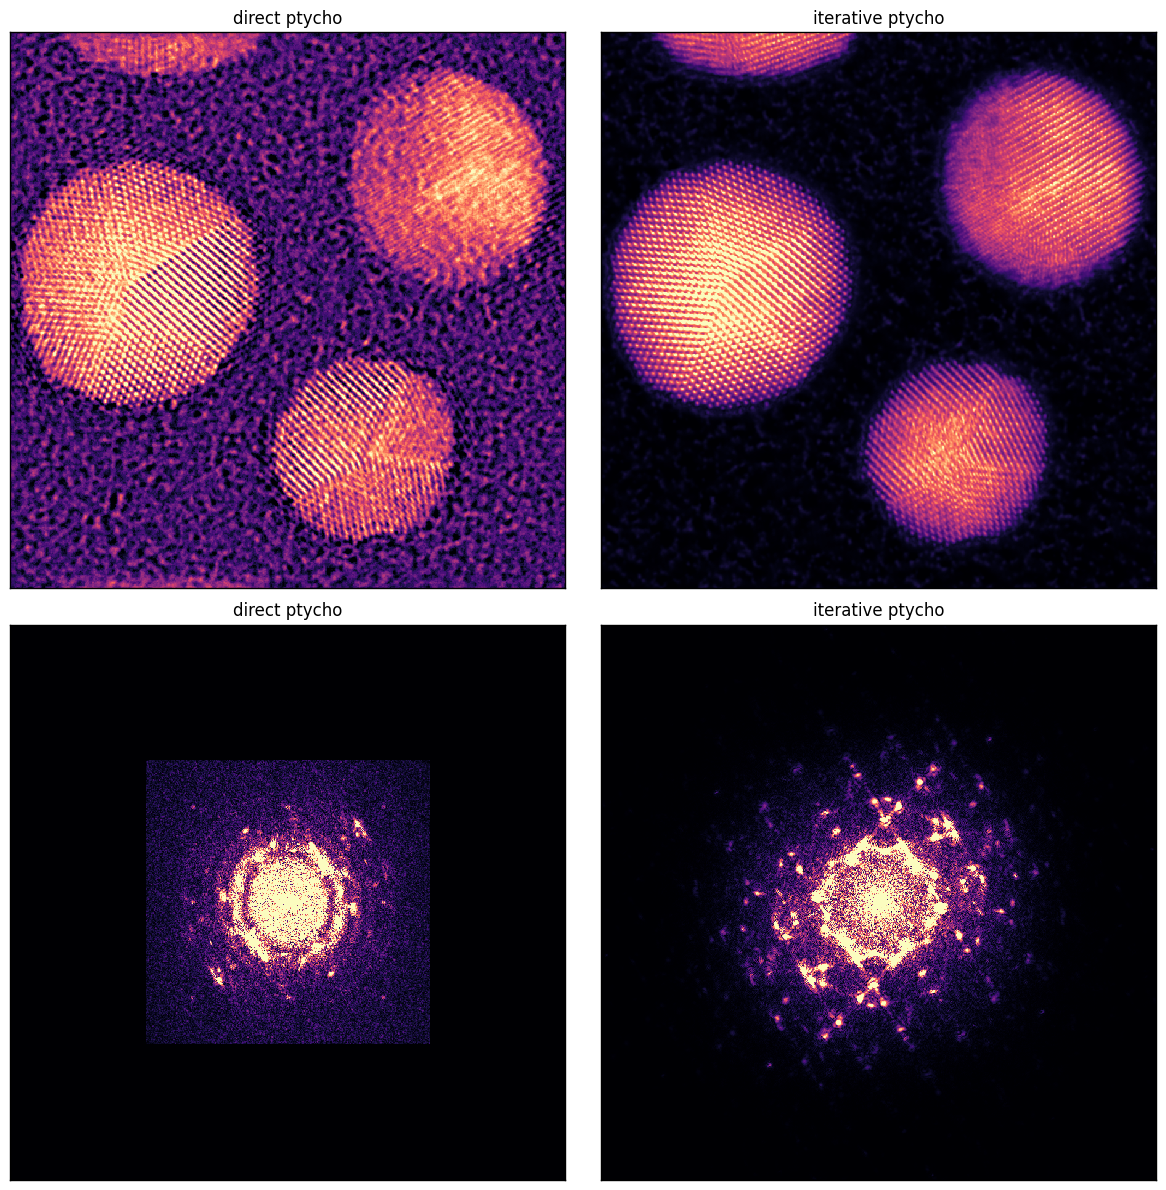

In [28]:
def fft(ar): 
    n0 = ar.shape
    w0 = np.hanning(n0[1]) * np.hanning(n0[0])[:, None]
    ar_fft = np.abs(np.fft.fftshift(np.fft.fft2(w0 * ar.copy())))
    return ar_fft

norm = em.visualization.NormalizationConfig(
    lower_quantile=0.1,
    upper_quantile=0.99,
    power = 0.5
)
 

pad = (ptycho_pix.obj_cropped.shape[1] - initial_parallax.obj.shape[0])//2

show_2d(
    [[
        initial_parallax.obj,
        ptycho_dip.obj_cropped.sum(0),
    ],

    [
        np.pad(
            fft(initial_parallax.obj),
            (
                (pad, pad),
                (pad, pad)
            )
        ),
        fft(ptycho_dip.obj_cropped.sum(0)),
    ]],
    cmap = "magma",
    title = ["direct ptycho", "iterative ptycho"],
    axsize = (6,6),
)

In [29]:
import h5py
from datetime import datetime

savedir = "recons"

now = datetime.now().strftime("%y%m%d_%H%M")

In [30]:
# Save direct version
with h5py.File(f"{savedir}/{now}_gold_ptycho_direct.h5", 'w') as f:
    print(f)
    f.create_dataset('obj_cropped', data=initial_parallax.obj, compression='gzip')


# Save pixelated version
with h5py.File( f"{savedir}/{now}_gold_ptycho_pix.h5", 'w') as f:
    print(f)
    f.create_dataset('obj_cropped', data=ptycho_pix.obj_cropped, compression='gzip')
    f.create_dataset('probe', data=ptycho_pix.probe, compression='gzip')
    f.attrs['model_type'] = 'pixelated'

# Save dgp version
with h5py.File(f"{savedir}/{now}_gold_ptycho_dip.h5", 'w') as f:
    f.create_dataset('obj_cropped', data=ptycho_dip.obj_cropped, compression='gzip')
    f.create_dataset('probe', data=ptycho_dip.probe, compression='gzip')
    f.attrs['model_type'] = 'dgp'

<HDF5 file "251214_1139_gold_ptycho_direct.h5" (mode r+)>
<HDF5 file "251214_1139_gold_ptycho_pix.h5" (mode r+)>


Iter 10/10, Loss: 1.042e+03: 100%|██████████████| 10/10 [06:20<00:00, 38.08s/it]


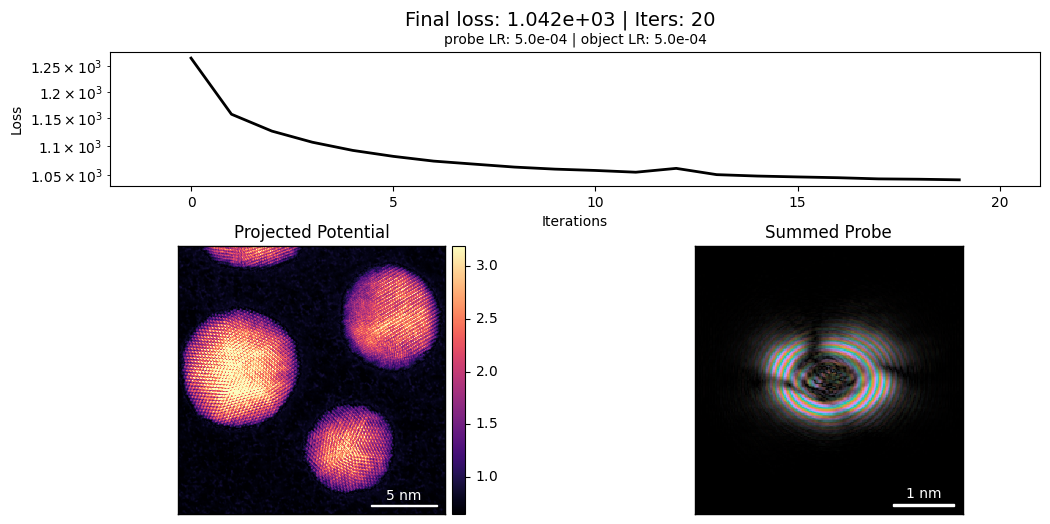

In [31]:

constraints = {
    "object":{
        "fix_potential_baseline": True,
        "fix_potential_baseline_factor": 0.5,
        # "tv_weight_z": 1000,
        # "positivity": False,
        "q_lowpass": 1.5,
        "identical_slices":True,
    }
}

ptycho_dip.reconstruct(
    num_iters=10, 
    reset=False, 
    scheduler_type='plateau', 
    batch_size=256,
    constraints=constraints
).visualize()


(<Figure size 1200x1200 with 4 Axes>,
 array([[<Axes: title={'center': 'direct ptycho'}>,
         <Axes: title={'center': 'iterative ptycho'}>],
        [<Axes: title={'center': 'direct ptycho'}>,
         <Axes: title={'center': 'iterative ptycho'}>]], dtype=object))

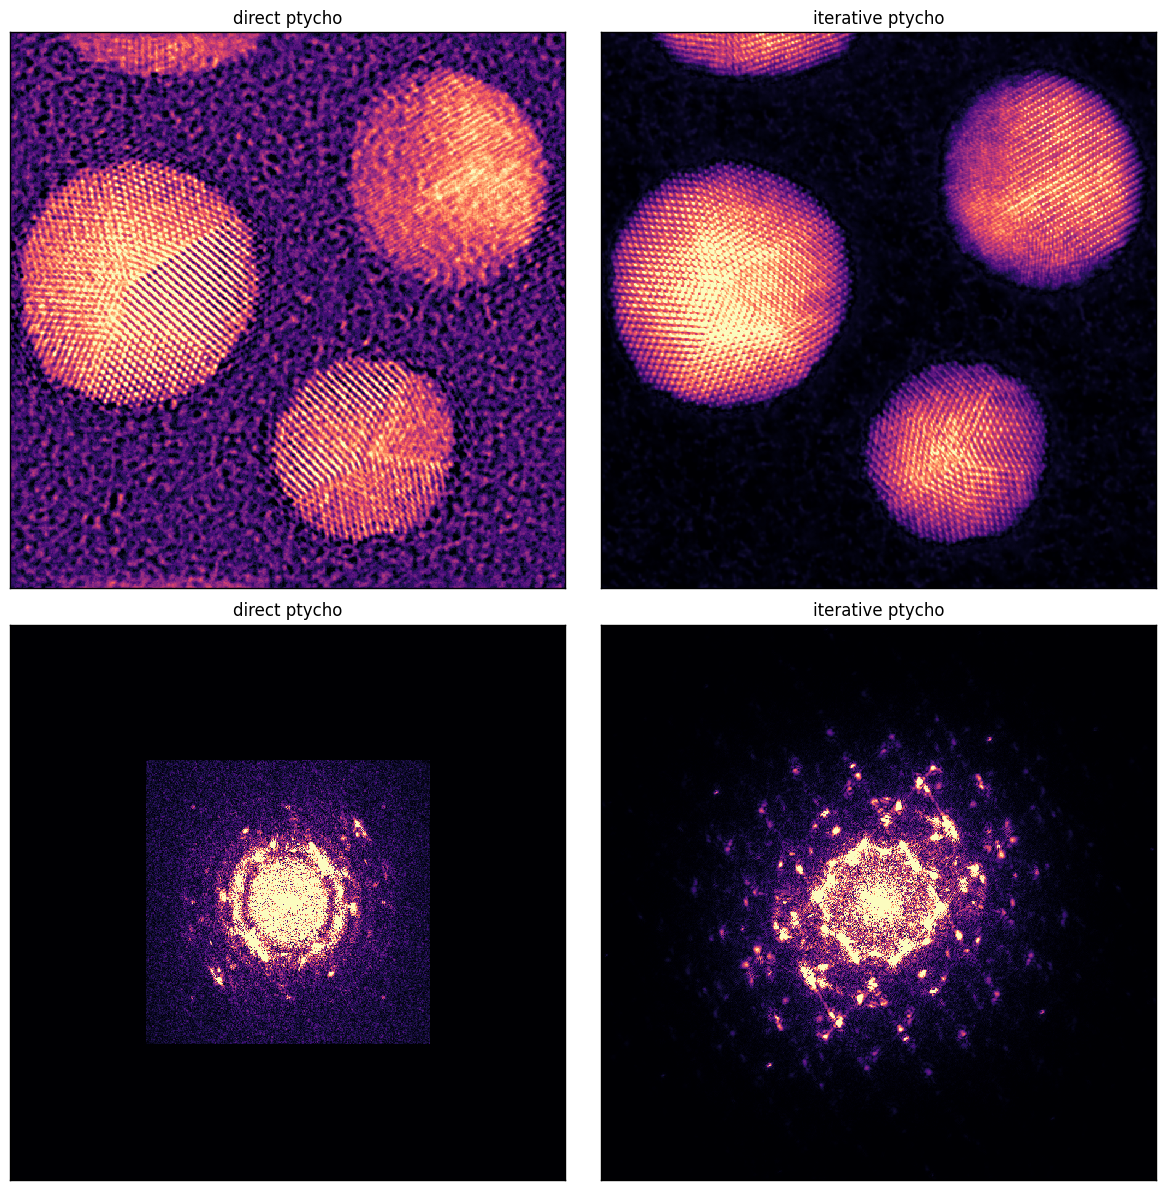

In [33]:
def fft(ar): 
    n0 = ar.shape
    w0 = np.hanning(n0[1]) * np.hanning(n0[0])[:, None]
    ar_fft = np.abs(np.fft.fftshift(np.fft.fft2(w0 * ar.copy())))
    return ar_fft

norm = em.visualization.NormalizationConfig(
    lower_quantile=0.1,
    upper_quantile=0.99,
    power = 0.5
)
 

pad = (ptycho_pix.obj_cropped.shape[1] - initial_parallax.obj.shape[0])//2

show_2d(
    [[
        # dset.virtual_images['DF'].array,
        initial_parallax.obj,
        ptycho_dip.obj_cropped.sum(0),
    ],

    [
        # dset.virtual_images['DF'].array,
        np.pad(
            fft(initial_parallax.obj),
            (
                (pad, pad),
                (pad, pad)
            )
        ),
        fft(ptycho_dip.obj_cropped.sum(0)),
    ]],
    cmap = "magma",
    title = ["direct ptycho", "iterative ptycho"],
    # minmax = None,
    axsize = (6,6),
    # norm = [norm, norm]
)

In [34]:
import matplotlib.pyplot as plt

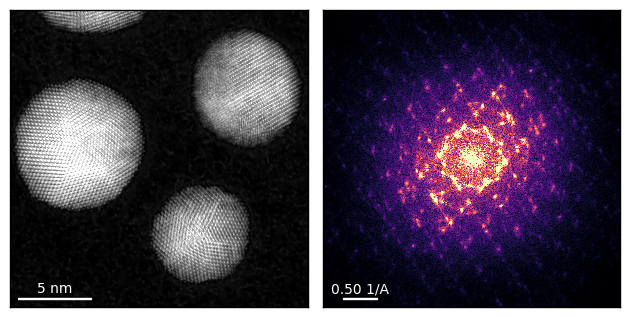

In [35]:
fig, ax = plt.subplots(1,2)

em.visualization.show_2d(
      ptycho_dip.obj_cropped.sum(0),
      figax = (fig, ax[0]), 
      scalebar = {
        'sampling':ptycho_dip.sampling[0]/10,
        'units':'nm',
        'length':5,
        'loc':3,   
    }
)


em.visualization.show_2d(
      fft(ptycho_dip.obj_cropped.sum(0)),
      figax = (fig, ax[1]), 
      scalebar = {
        'sampling':np.fft.fftfreq(ptycho_dip.obj_cropped.shape[1],ptycho_dip.sampling[0])[1],
        'units':'1/A',
        'length':0.5,
        'loc':3,   
     },
     norm = norm,
      cmap = "magma"
)


plt.savefig('gold_iterative_calibration.pdf', bbox_inches = "tight")

In [36]:
# Save direct version
with h5py.File(f"{savedir}/{now}_gold_ptycho_direct.h5", 'w') as f:
    print(f)
    f.create_dataset('obj_cropped', data=initial_parallax.obj, compression='gzip')


# Save pixelated version
with h5py.File( f"{savedir}/{now}_gold_ptycho_pix.h5", 'w') as f:
    print(f)
    f.create_dataset('obj_cropped', data=ptycho_pix.obj_cropped, compression='gzip')
    f.create_dataset('probe', data=ptycho_pix.probe, compression='gzip')
    f.attrs['model_type'] = 'pixelated'

# Save dgp version
with h5py.File(f"{savedir}/{now}_gold_ptycho_dip.h5", 'w') as f:
    f.create_dataset('obj_cropped', data=ptycho_dip.obj_cropped, compression='gzip')
    f.create_dataset('probe', data=ptycho_dip.probe, compression='gzip')
    f.attrs['model_type'] = 'dgp'

<HDF5 file "251214_1139_gold_ptycho_direct.h5" (mode r+)>
<HDF5 file "251214_1139_gold_ptycho_pix.h5" (mode r+)>
